# Analyse Exploratoire des Données (EDA)
Ce notebook est utilisé pour explorer et analyser le dataset CNN/DailyMail.

In [2]:
# Cellule 1 : Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries importées")
print(f" Matplotlib: {plt.matplotlib.__version__}")
print(f" Seaborn: {sns.__version__}")


Libraries importées
 Matplotlib: 3.11.1
 Seaborn: 0.13.2


In [3]:
# Cellule 2 : Chargement du dataset
print("=" * 60)
print(" CHARGEMENT DU DATASET")
print("=" * 60)

from datasets import load_dataset

print("\n Chargement depuis les fichiers Parquet...")

# Charger les splits
train_dataset = load_dataset("parquet", data_dir="data/raw", split="train")
val_dataset = load_dataset("parquet", data_dir="data/raw", split="validation")
test_dataset = load_dataset("parquet", data_dir="data/raw", split="test")

dataset = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}

print(" Dataset chargé !")
print(f"   • Train: {len(train_dataset):,} exemples")
print(f"   • Validation: {len(val_dataset):,} exemples")
print(f"   • Test: {len(test_dataset):,} exemples")


 CHARGEMENT DU DATASET

 Chargement depuis les fichiers Parquet...
 Dataset chargé !
   • Train: 287,113 exemples
   • Validation: 13,368 exemples
   • Test: 11,490 exemples


In [6]:
# Cellule 3 : Statistiques de base
print("\n" + "=" * 60)
print(" STATISTIQUES DESCRIPTIVES")
print("=" * 60)

# Créer un DataFrame avec un échantillon (pour aller plus vite)
print("\n Création de l'échantillon (5000 exemples)...")
sample_size = 5000
sample_data = []

for i in range(min(sample_size, len(train_dataset))):
    example = train_dataset[i]
    sample_data.append({
        'article': example['article'],
        'summary': example['highlights']
    })

df = pd.DataFrame(sample_data)

# Calculer les longueurs
df['article_length'] = df['article'].apply(len)
df['summary_length'] = df['summary'].apply(len)
df['article_words'] = df['article'].apply(lambda x: len(x.split()))
df['summary_words'] = df['summary'].apply(lambda x: len(x.split()))
df['ratio'] = df['summary_length'] / df['article_length']

print(" DataFrame créé !")

# Statistiques générales
print("\n1. APERÇU DU DATAFRAME:")
print(df.head())
print(f"\n2. TAILLE: {len(df):,} exemples")

print("\n3. STATISTIQUES DES ARTICLES:")
print(df['article_length'].describe())

print("\n4. STATISTIQUES DES RÉSUMÉS:")
print(df['summary_length'].describe())
print("skai")
print(df.describe())



 STATISTIQUES DESCRIPTIVES

 Création de l'échantillon (5000 exemples)...
 DataFrame créé !

1. APERÇU DU DATAFRAME:
                                             article  \
0  LONDON, England (Reuters) -- Harry Potter star...   
1  Editor's note: In our Behind the Scenes series...   
2  MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...   
3  WASHINGTON (CNN) -- Doctors removed five small...   
4  (CNN)  -- The National Football League has ind...   

                                             summary  article_length  \
0  Harry Potter star Daniel Radcliffe gets £20M f...            2527   
1  Mentally ill inmates in Miami are housed on th...            4051   
2  NEW: "I thought I was going to die," driver sa...            3940   
3  Five small polyps found during procedure; "non...            2620   
4  NEW: NFL chief, Atlanta Falcons owner critical...            5764   

   summary_length  article_words  summary_words     ratio  
0             217            455             41  0.0


 ANALYSE DES DISTRIBUTIONS
 Graphique sauvegardé dans outputs/figures/eda_distributions.png


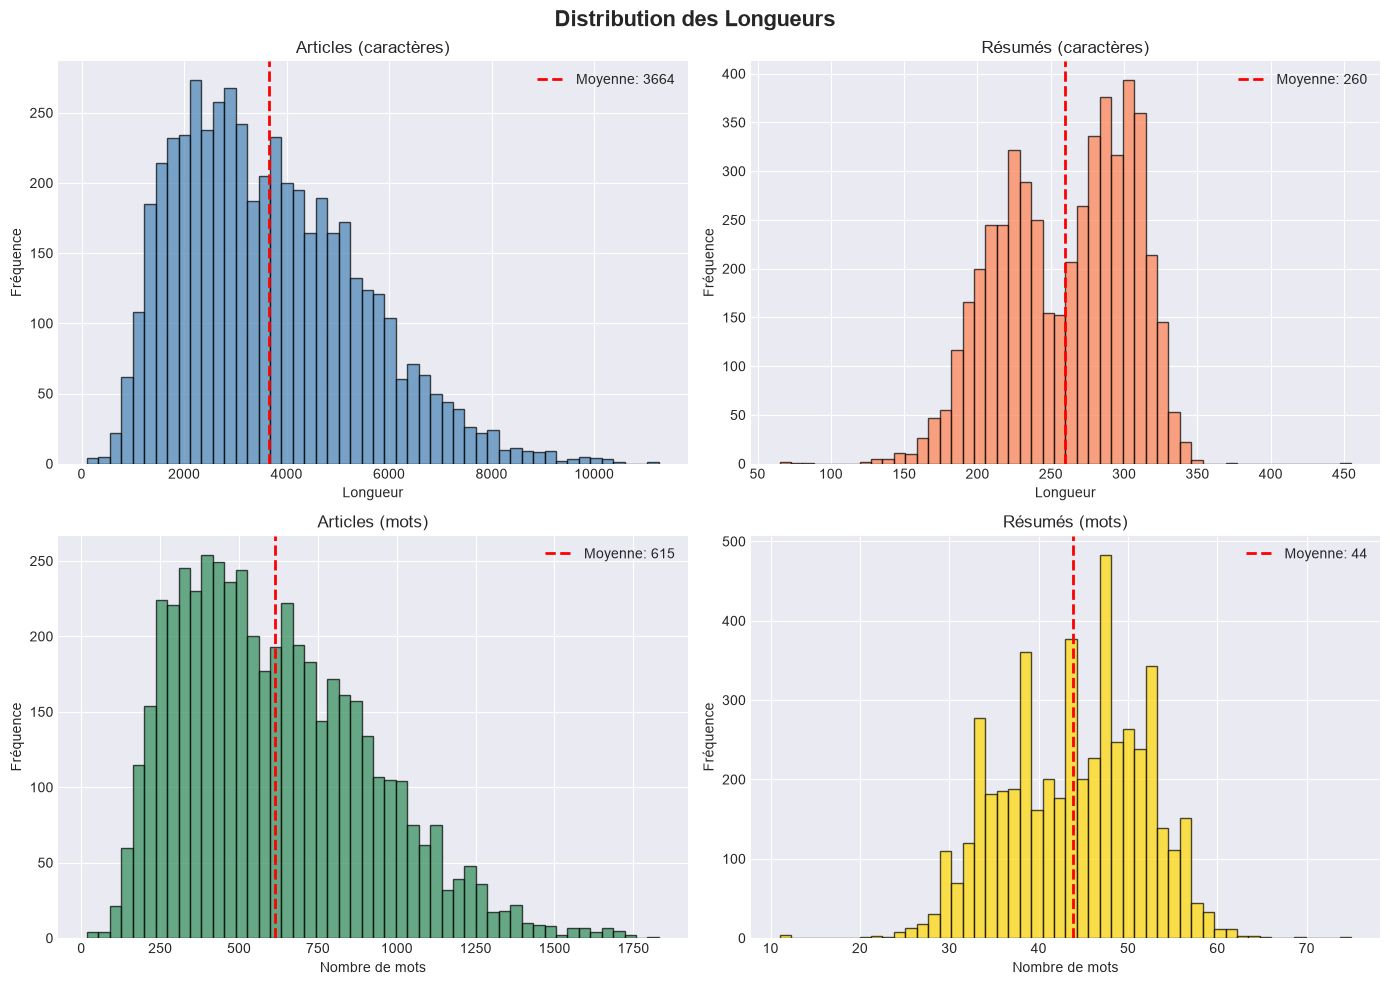

In [7]:
# Cellule 4 : Analyse des distributions
print("\n" + "=" * 60)
print(" ANALYSE DES DISTRIBUTIONS")
print("=" * 60)

# Créer les visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution des Longueurs', fontsize=16, fontweight='bold')

# Distribution des articles (caractères)
axes[0, 0].hist(df['article_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['article_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["article_length"].mean():.0f}')
axes[0, 0].set_title('Articles (caractères)')
axes[0, 0].set_xlabel('Longueur')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].legend()

# Distribution des résumés (caractères)
axes[0, 1].hist(df['summary_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['summary_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["summary_length"].mean():.0f}')
axes[0, 1].set_title('Résumés (caractères)')
axes[0, 1].set_xlabel('Longueur')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].legend()

# Distribution des articles (mots)
axes[1, 0].hist(df['article_words'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['article_words'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["article_words"].mean():.0f}')
axes[1, 0].set_title('Articles (mots)')
axes[1, 0].set_xlabel('Nombre de mots')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# Distribution des résumés (mots)
axes[1, 1].hist(df['summary_words'], bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df['summary_words'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["summary_words"].mean():.0f}')
axes[1, 1].set_title('Résumés (mots)')
axes[1, 1].set_xlabel('Nombre de mots')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/eda_distributions.png', dpi=300, bbox_inches='tight')
print(" Graphique sauvegardé dans outputs/figures/eda_distributions.png")
plt.show()


In [8]:
# Cellule 5 : Analyse du vocabulaire
print("\n" + "=" * 60)
print(" ANALYSE DU VOCABULAIRE")
print("=" * 60)

# Fonction pour extraire les mots
def get_words(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower())

# Analyser les articles
print("\n Analyse du vocabulaire (cela peut prendre 1-2 min)...")

all_article_words = []
all_summary_words = []

for i in range(min(2000, len(df))):
    article = df.iloc[i]['article']
    summary = df.iloc[i]['summary']
    
    all_article_words.extend(get_words(article))
    all_summary_words.extend(get_words(summary))

# Compter les fréquences
article_word_freq = Counter(all_article_words)
summary_word_freq = Counter(all_summary_words)

print("\n1. VOCABULAIRE DES ARTICLES:")
print(f"   • Nombre total de mots: {len(all_article_words):,}")
print(f"   • Mots uniques: {len(article_word_freq):,}")
print(f"   • Top 10 mots les plus fréquents:")
for word, count in article_word_freq.most_common(10):
    print(f"     - {word:15s}: {count:>6,} fois")

print("\n2. VOCABULAIRE DES RÉSUMÉS:")
print(f"   • Nombre total de mots: {len(all_summary_words):,}")
print(f"   • Mots uniques: {len(summary_word_freq):,}")
print(f"   • Top 10 mots les plus fréquents:")
for word, count in summary_word_freq.most_common(10):
    print(f"     - {word:15s}: {count:>6,} fois")



 ANALYSE DU VOCABULAIRE

 Analyse du vocabulaire (cela peut prendre 1-2 min)...

1. VOCABULAIRE DES ARTICLES:
   • Nombre total de mots: 1,208,811
   • Mots uniques: 37,197
   • Top 10 mots les plus fréquents:
     - the            : 72,417 fois
     - to             : 32,949 fois
     - of             : 29,885 fois
     - a              : 29,729 fois
     - and            : 29,110 fois
     - in             : 26,603 fois
     - s              : 16,583 fois
     - said           : 13,304 fois
     - that           : 13,279 fois
     - for            : 10,864 fois

2. VOCABULAIRE DES RÉSUMÉS:
   • Nombre total de mots: 80,267
   • Mots uniques: 11,490
   • Top 10 mots les plus fréquents:
     - in             :  2,142 fois
     - to             :  2,113 fois
     - of             :  1,943 fois
     - the            :  1,861 fois
     - s              :  1,376 fois
     - a              :  1,109 fois
     - says           :    938 fois
     - and            :    860 fois
     - for     

In [9]:
# Cellule 6 : Détection d'anomalies
print("\n" + "=" * 60)
print(" DÉTECTION D'ANOMALIES")
print("=" * 60)

# Articles vides
empty_articles = df[df['article'].str.strip() == '']
print(f"\n1. ARTICLES VIDES: {len(empty_articles)}")

# Résumés vides
empty_summaries = df[df['summary'].str.strip() == '']
print(f"2. RÉSUMÉS VIDES: {len(empty_summaries)}")

# Résumés plus longs que les articles
weird_summaries = df[df['summary_length'] > df['article_length']]
print(f"3. RÉSUMÉS PLUS LONGS QUE LES ARTICLES: {len(weird_summaries)}")

# Articles très courts (< 100 caractères)
short_articles = df[df['article_length'] < 100]
print(f"4. ARTICLES TRÈS COURTS (< 100 car.): {len(short_articles)}")

# Résumés très longs (> 500 caractères)
long_summaries = df[df['summary_length'] > 500]
print(f"5. RÉSUMÉS TRÈS LONGS (> 500 car.): {len(long_summaries)}")

# Présence de URLs
url_pattern = r'http\S+|www\S+'
articles_with_urls = df[df['article'].str.contains(url_pattern, regex=True)]
print(f"6. ARTICLES AVEC URLs: {len(articles_with_urls)}")

# Présence d'emails
email_pattern = r'\S+@\S+'
articles_with_emails = df[df['article'].str.contains(email_pattern, regex=True)]
print(f"7. ARTICLES AVEC EMAILS: {len(articles_with_emails)}")

# Afficher des exemples d'anomalies
if len(short_articles) > 0:
    print(f"\n EXEMPLE D'ARTICLE COURT:")
    print(f"   '{short_articles.iloc[0]['article'][:200]}'")
    print(f"   Résumé: '{short_articles.iloc[0]['summary'][:100]}'")



 DÉTECTION D'ANOMALIES

1. ARTICLES VIDES: 0
2. RÉSUMÉS VIDES: 0
3. RÉSUMÉS PLUS LONGS QUE LES ARTICLES: 3
4. ARTICLES TRÈS COURTS (< 100 car.): 0
5. RÉSUMÉS TRÈS LONGS (> 500 car.): 0
6. ARTICLES AVEC URLs: 62
7. ARTICLES AVEC EMAILS: 13



🎨 VISUALISATIONS AVANCÉES


C:\Users\ksenou\AppData\Local\Temp\ipykernel_14264\2378329825.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 0].boxplot(df['article_words'], vert=True)
C:\Users\ksenou\AppData\Local\Temp\ipykernel_14264\2378329825.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(df['summary_words'], vert=True)


 Graphique sauvegardé dans outputs/figures/eda_advanced.png


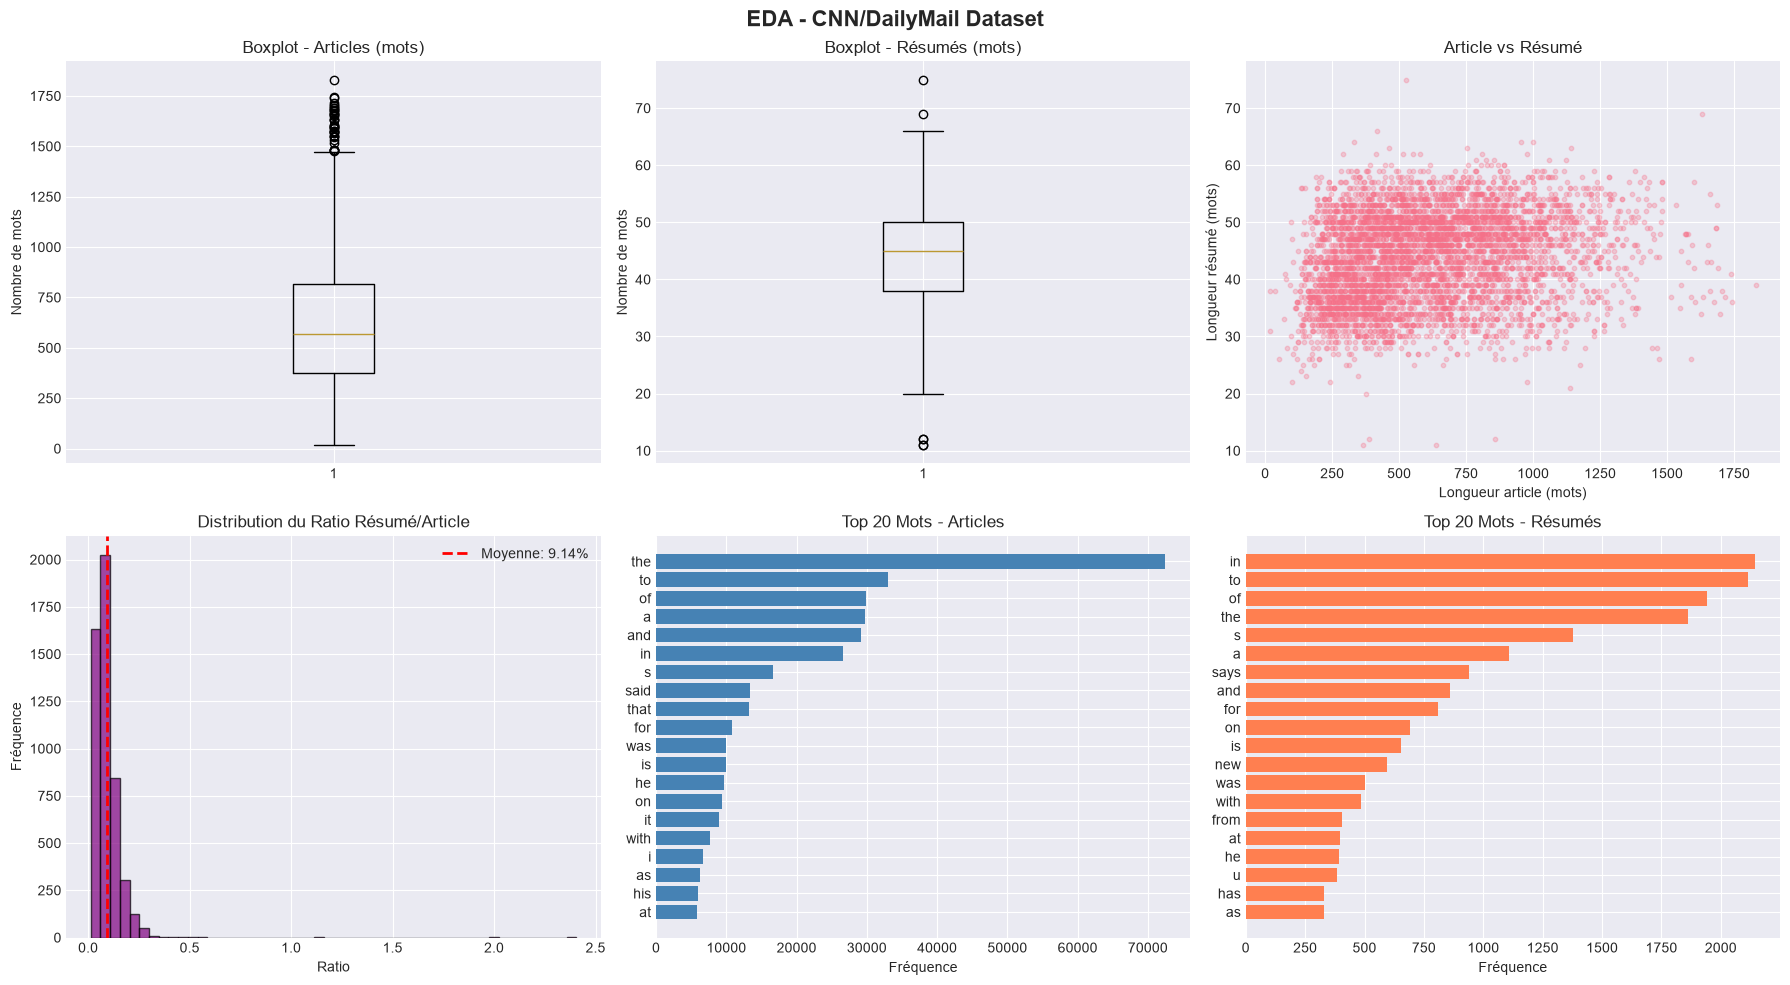

In [ ]:
# Cellule 7 : Visualisations avancées
print("\n" + "=" * 60)
print(" VISUALISATIONS AVANCÉES")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA - CNN/DailyMail Dataset', fontsize=16, fontweight='bold')

# 1. Boxplot des longueurs d'articles
axes[0, 0].boxplot(df['article_words'], vert=True)
axes[0, 0].set_title('Boxplot - Articles (mots)')
axes[0, 0].set_ylabel('Nombre de mots')

# 2. Boxplot des longueurs de résumés
axes[0, 1].boxplot(df['summary_words'], vert=True)
axes[0, 1].set_title('Boxplot - Résumés (mots)')
axes[0, 1].set_ylabel('Nombre de mots')

# 3. Scatter plot : article vs résumé
axes[0, 2].scatter(df['article_words'], df['summary_words'], alpha=0.3, s=10)
axes[0, 2].set_xlabel('Longueur article (mots)')
axes[0, 2].set_ylabel('Longueur résumé (mots)')
axes[0, 2].set_title('Article vs Résumé')

# 4. Distribution du ratio
axes[1, 0].hist(df['ratio'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["ratio"].mean():.2%}')
axes[1, 0].set_title('Distribution du Ratio Résumé/Article')
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# 5. Top 20 mots dans les articles
top_words = article_word_freq.most_common(20)
words = [w for w, c in top_words]
counts = [c for w, c in top_words]
axes[1, 1].barh(words[::-1], counts[::-1], color='steelblue')
axes[1, 1].set_title('Top 20 Mots - Articles')
axes[1, 1].set_xlabel('Fréquence')

# 6. Top 20 mots dans les résumés
top_summary_words = summary_word_freq.most_common(20)
words_s = [w for w, c in top_summary_words]
counts_s = [c for w, c in top_summary_words]
axes[1, 2].barh(words_s[::-1], counts_s[::-1], color='coral')
axes[1, 2].set_title('Top 20 Mots - Résumés')
axes[1, 2].set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('outputs/figures/eda_advanced.png', dpi=300, bbox_inches='tight')
print(" Graphique sauvegardé dans outputs/figures/eda_advanced.png")
plt.show()


In [11]:
# Cellule 8 : Conclusions
print("\n" + "=" * 60)
print(" CONCLUSIONS DE L'EDA")
print("=" * 60)

print("\n POINTS CLÉS:")
print(f"1. Dataset de taille importante: {len(train_dataset):,} exemples d'entraînement")
print(f"2. Articles longs: ~{df['article_words'].mean():.0f} mots en moyenne")
print(f"3. Résumés courts: ~{df['summary_words'].mean():.0f} mots en moyenne")
print(f"4. Ratio résumé/article: {df['ratio'].mean():.2%}")
print(f"5. Vocabulaire riche: {len(article_word_freq):,} mots uniques dans les articles")

print("\n ANOMALIES DÉTECTÉES:")
print(f"   • {len(empty_articles)} articles vides")
print(f"   • {len(empty_summaries)} résumés vides")
print(f"   • {len(short_articles)} articles très courts")
print(f"   • {len(articles_with_urls)} articles avec URLs")

print("\n RECOMMANDATIONS:")
print("1. Le dataset est prêt pour l'entraînement")
print("2. Utiliser max_length=512 pour les articles")
print("3. Utiliser max_length=128 pour les résumés")
print("4. Le tokenizer T5 fonctionnera bien sur ce dataset")
print("5. Pas besoin de filtrage supplémentaire")

print("\n" + "=" * 60)
print(" EDA TERMINÉE !")
print("=" * 60)



 CONCLUSIONS DE L'EDA

 POINTS CLÉS:
1. Dataset de taille importante: 287,113 exemples d'entraînement
2. Articles longs: ~615 mots en moyenne
3. Résumés courts: ~44 mots en moyenne
4. Ratio résumé/article: 9.14%
5. Vocabulaire riche: 37,197 mots uniques dans les articles

 ANOMALIES DÉTECTÉES:
   • 0 articles vides
   • 0 résumés vides
   • 0 articles très courts
   • 62 articles avec URLs

 RECOMMANDATIONS:
1. Le dataset est prêt pour l'entraînement
2. Utiliser max_length=512 pour les articles
3. Utiliser max_length=128 pour les résumés
4. Le tokenizer T5 fonctionnera bien sur ce dataset
5. Pas besoin de filtrage supplémentaire

 EDA TERMINÉE !
